In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d
from scipy import signal
from scipy.ndimage import gaussian_filter1d

In [9]:
matplotlib.rc('text', usetex = True)

In [10]:
RbbB = pd.read_csv('RbbB.csv',header = None, sep='\t')
RbqB = pd.read_csv('RbqB.csv',header = None, sep='\t')
RbsB = pd.read_csv('RbsB.csv',header = None, sep='\t')
RqbQ = pd.read_csv('RbqQ.csv',header = None, sep='\t')
RqqQ = pd.read_csv('RqqQ.csv',header = None, sep='\t')
RqsQ = pd.read_csv('RqsQ.csv',header = None, sep='\t')
RsbS = pd.read_csv('RsbS.csv',header = None, sep='\t')
RsqS = pd.read_csv('RsqS.csv',header = None, sep='\t')
RssS = pd.read_csv('RssS.csv',header = None, sep='\t')

RkT1B = pd.read_csv('RkT1B.csv',header = None, sep='\t')
RkT2B = pd.read_csv('RkT2B.csv',header = None, sep='\t')
RkT3B = pd.read_csv('RkT3B.csv',header = None, sep='\t')

In [11]:
#1
bbbBt = RbbB[0]
bbbB1 = RbbB[1]
bbbB2 = RbbB[2]
bbbB3 = RbbB[3]

#2
bbqBt = RbqB[0]
bbqB1 = RbqB[1]
bbqB2 = RbqB[2]
bbqB3 = RbqB[3]

#3
bbsBt = RbsB[0]
bbsB1 = RbsB[1]

#4
bqbQt = RqbQ[0]
bqbQ1 = RqbQ[1]
bqbQ2 = RqbQ[2]
bqbQ3 = RqbQ[3]

#5
bqqQt = RqqQ[0]
bqqQ1 = RqqQ[1]
bqqQ2 = RqqQ[2]
bqqQ3 = RqqQ[3]

#6
bqsQt = RqsQ[0]
bqsQ1 = RqsQ[1]

#7
bsbSt = RsbS[0]
bsbS1 = RsbS[1]

#8
bsqSt = RsqS[0]
bsqS1 = RsqS[1]

#9
bssSt = RssS[0]
bssS1 = RssS[1]

In [12]:
RkT1t = RkT1B[0]
RkT1 = RkT1B[1]

RkT2t = RkT2B[0]
RkT2 = RkT2B[1]

RkT3t = RkT3B[0]
RkT3 = RkT3B[1]

In [13]:
plt.rc('text', usetex=True)
plt.rc('font', family='Times New Roman',size=12)
plt.rcParams['mathtext.fontset']='custom'
plt.rcParams['mathtext.rm']='Times New Roman'
plt.rcParams['font.family']='Times New Roman'

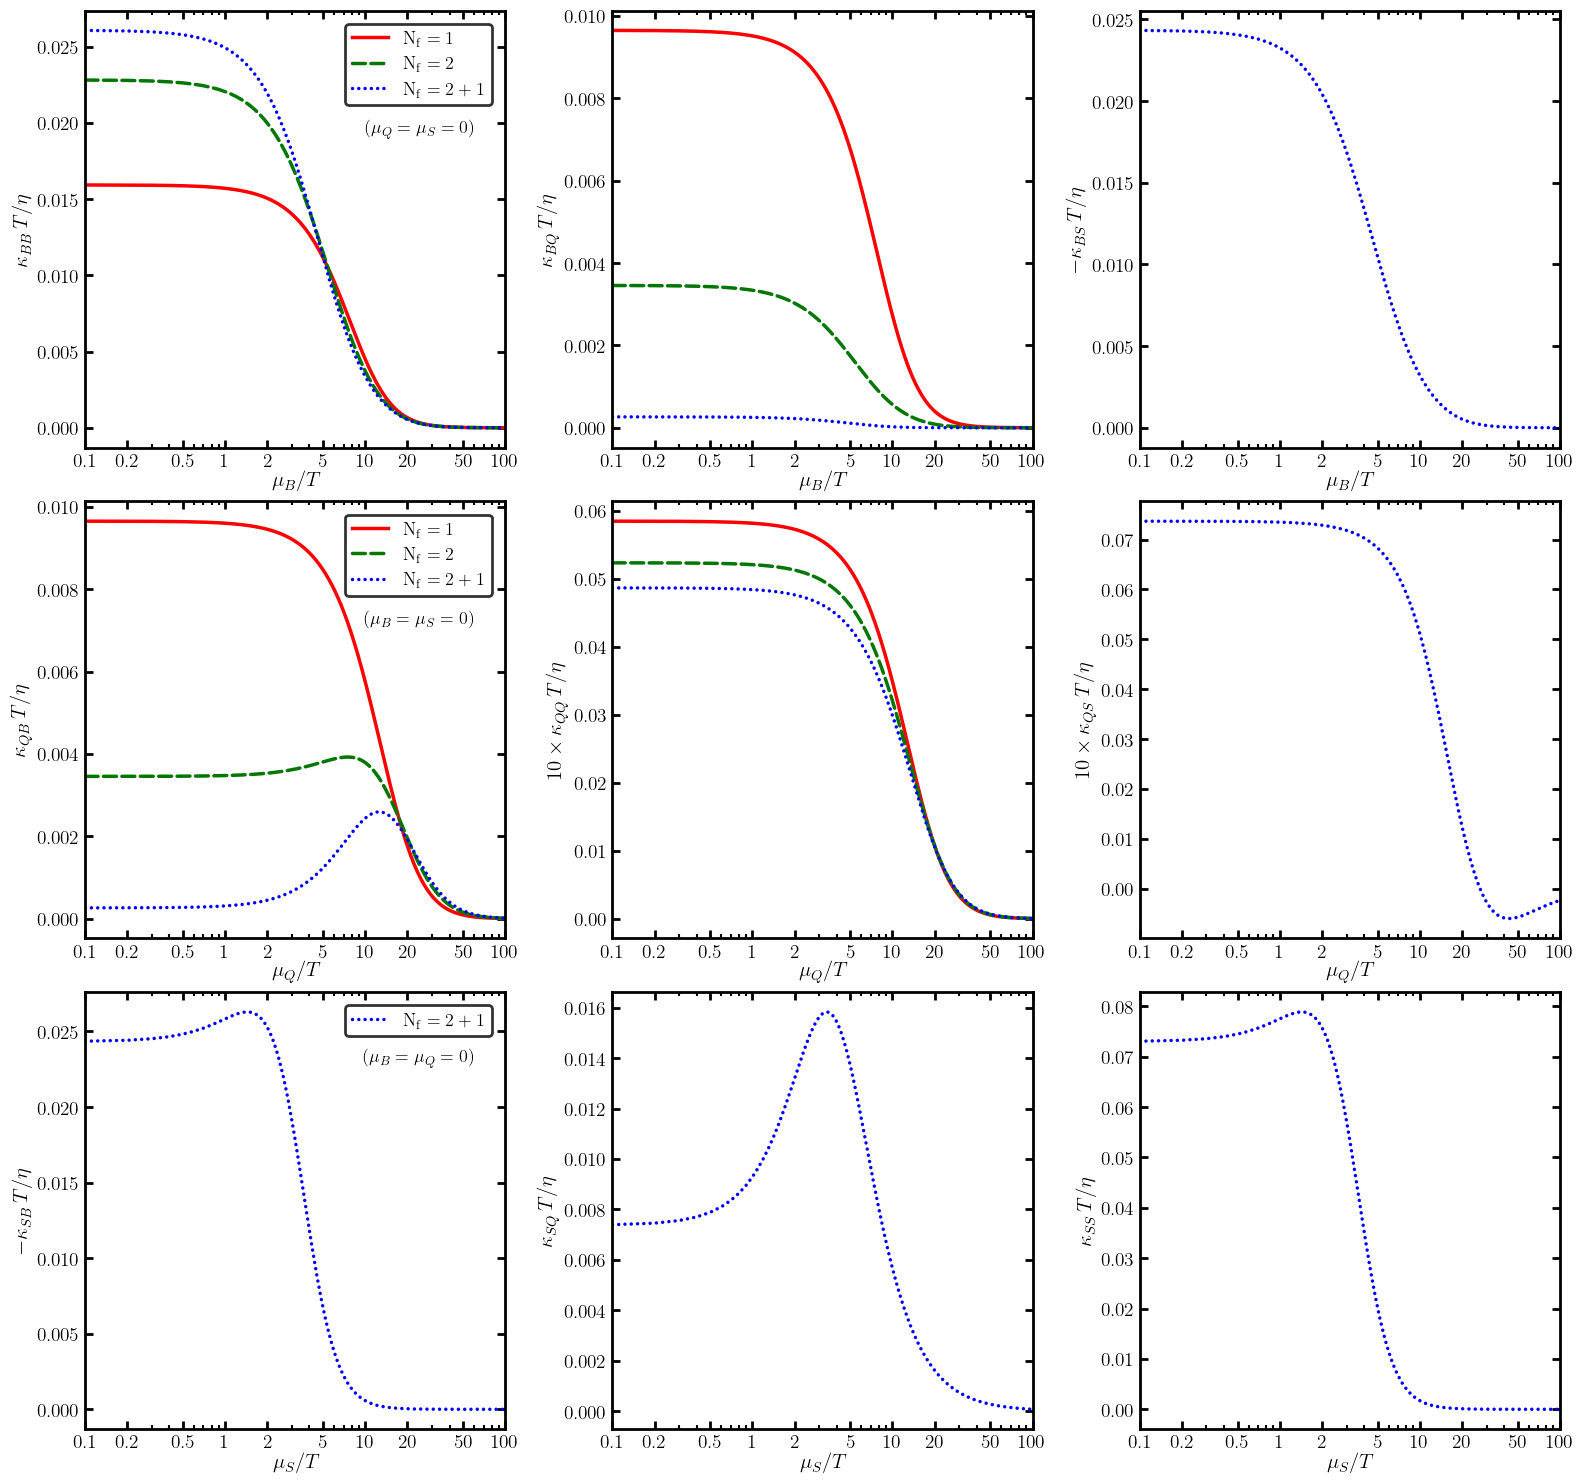

In [7]:
# 1. Organizing the variables
panels_data1 = [
    [bbbBt, bbbB1, bbbB2, bbbB3],    # 0: k_bb (Row 1, Col 1) - 3 curves
    [bbqBt, bbqB1, bbqB2, bbqB3],    # 1: k_bq (Row 1, Col 2) - 3 curves
    [bbsBt, -bbsB1],                 # 2: k_bs (Row 1, Col 3) - 1 curve (Nf = 2+1)
    [bqbQt, bqbQ1, bqbQ2, bqbQ3],    # 3: k_qb (Row 2, Col 1) - 3 curves
    [bqqQt, 10*bqqQ1, 10*bqqQ2, 10*bqqQ3],    # 4: k_qq (Row 2, Col 2) - 3 curves
    [bqsQt, 10*bqsQ1],                  # 5: k_qs (Row 2, Col 3) - 1 curve (Nf = 2+1)
    [bsbSt, -bsbS1],                 # 6: k_sb (Row 3, Col 1) - 1 curve (Nf = 2+1)
    [bsqSt, bsqS1],                  # 7: k_sq (Row 3, Col 2) - 1 curve (Nf = 2+1)
    [bssSt, bssS1],                  # 8: k_ss (Row 3, Col 3) - 1 curve (Nf = 2+1)
]

# 2. Styles for the 3 main curves
colors = ['#ff0000', '#007700', '#0000ff']
# The gap parameter is reduced to 1.8 to significantly increase dot density
styles = ['-', '--', (0, (0.01, 1.8))] 

# 3. Dedicated Y-Axis and X-Axis Label Arrays
y_labels = [
    "$\\kappa_{BB}\\,T/\\eta$", "$\\kappa_{BQ}\\,T/\\eta$", "$-\\kappa_{BS}\\,T/\\eta$",
    "$\\kappa_{QB}\\,T/\\eta$", "$10\\times\\kappa_{QQ}\\,T/\\eta$", "$10\\times\\kappa_{QS}\\,T/\\eta$",
    "$-\\kappa_{SB}\\,T/\\eta$", "$\\kappa_{SQ}\\,T/\\eta$", "$\\kappa_{SS}\\,T/\\eta$",
]

x_labels = [
    "$\\mu_{B}/T$", "$\\mu_{B}/T$", "$\\mu_{B}/T$",
    "$\\mu_{Q}/T$", "$\\mu_{Q}/T$", "$\\mu_{Q}/T$",
    "$\\mu_{S}/T$", "$\\mu_{S}/T$", "$\\mu_{S}/T$"
]

# 4. Plot Legends
plot_legend = [
    ["${\\rm N_{f}} = 1$", "${\\rm N_{f}} = 2$", "${\\rm N_{f}} = 2+1$", "$(\\mu_{S} = \\mu_Q = 0)$"],
    ["${\\rm N_{f}} = 1$", "${\\rm N_{f}} = 2$", "${\\rm N_{f}} = 2+1$", "$(\\mu_{S} = \\mu_B = 0)$"],
    ["${\\rm N_{f}} = 1$", "${\\rm N_{f}} = 2$", "${\\rm N_{f}} = 2+1$", "$(\\mu_{Q} = \\mu_B = 0)$"]
]

# Mapping chemical potential texts for panels (1,1), (2,1), and (3,1)
panel_conditions = {
    0: "$(\\mu_Q = \\mu_S = 0)$",
    3: "$(\\mu_B = \\mu_S = 0)$",
    6: "$(\\mu_B = \\mu_Q = 0)$"
}

# Legend configuration settings
leg_locs = {
    0: 'upper right',  # Row 1 Left (Panel 0)
    3: 'upper right',  # Row 2 Left (Panel 3)
    6: 'upper right'   # Row 3 Left (Panel 6)
}

manual_anchors = {
    0: (0.99, 0.99),   
    3: (0.99, 0.99),   
    6: (0.99, 0.99)   
}

# Independent text coordinates (x, y) for the label below the legend
text_positions = {
    0: (0.93, 0.75),  # Position for Row 1 (Panel 0)
    3: (0.93, 0.75),  # Position for Row 2 (Panel 3)
    6: (0.93, 0.87)   # Position for Row 3 (Panel 6)
}

# Set global frame thickness properties
plt.rcParams['axes.linewidth'] = 2.0 
plt.rcParams['xtick.major.width'] = 2.0 
plt.rcParams['ytick.major.width'] = 2.0 
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['patch.linewidth'] = 2.0

fig, axes = plt.subplots(3, 3, figsize=(16, 15))
axes_flat = axes.flatten()

for i in range(9):
    ax = axes_flat[i]
    current_panel_data = panels_data1[i]

    ax.set_xscale('log')

    custom_ticks = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100]
    custom_labels = ["%g" % val for val in custom_ticks]
    
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels(custom_labels)
    
    # Enable ticks on all sides pointing inward
    ax.tick_params(axis='both', which='both', 
                   direction='in', 
                   top=True, 
                   right=True, 
                   labelsize=14,
                   width=2.0,      
                   length=6)      
    
    ax.tick_params(axis='both', which='minor', 
                   direction='in', 
                   top=True, 
                   right=True,
                   width=1.5,      
                   length=3)     
    
    # Safe unpacking
    x_val = current_panel_data[0]
    if len(current_panel_data) >= 5:
        y_vals = current_panel_data[1:4] 
        y_const = current_panel_data[4]  
    else:
        y_vals = current_panel_data[1:]
        y_const = None
    
    ax.margins(x=0)
    row_idx = i // 3

    # --- ADDING THE CONSTANT VALUE LINE ---
    if y_const is not None:
        ax.axhline(y=y_const, color='#00000000', linestyle='-.', linewidth=1.5, 
                   label=plot_legend[row_idx][3], zorder=1)
    
    # --- PLOTTING THE DATA CURVES WITH CORRECT INDEX ALIGNMENT ---
    is_single_curve_panel = i in [2, 5, 6, 7, 8]

    for j_idx, y_data in enumerate(y_vals):
        j = 2 if is_single_curve_panel else j_idx
            
        ax.plot(x_val, y_data,
                color=colors[j],
                linestyle=styles[j],
                linewidth=2.5,        # Retains proper line bounds to frame clean dots
                dash_capstyle='round', # Cuts the flat edges of line components into precise dots
                label=plot_legend[row_idx][j])
    
    ax.grid(True, alpha=0)

    # Set separate labels per subplot
    ax.set_ylabel(y_labels[i], fontsize=15, fontweight='bold', labelpad=4)
    ax.set_xlabel(x_labels[i], fontsize=15, fontweight='bold', labelpad=0)

    # --- MANUAL PLOT LEGENDS LOGIC ---
    if i in [0, 3, 6]:
        if i == 6:
            # Clean up text boxes for the last row's single curve layout
            handles, labels = ax.get_legend_handles_labels()
            filtered_handles = [h for h, l in zip(handles, labels) if l not in [" ${\\rm N_{f}} = 1$ ", " ${\\rm N_{f}} = 2$ "]]
            filtered_labels = [l for l in labels if l not in [" ${\\rm N_{f}} = 1$ ", " ${\\rm N_{f}} = 2$ "]]
            
            ax.legend(
                filtered_handles,
                filtered_labels,
                loc=leg_locs[i],
                bbox_to_anchor=manual_anchors[i],
                fontsize=13,
                frameon=True
            )
        else:
            # Standard legend layout for full 3-curve panels
            ax.legend(
                loc=leg_locs[i], 
                bbox_to_anchor=manual_anchors[i], 
                fontsize=13, 
                frameon=True
            )
        
        # --- ADDING TEXT BELOW LEGEND WITH INDEPENDENT POSITION CONTROL ---
        tx, ty = text_positions[i]
        
        ax.text(tx, ty, panel_conditions[i], 
                transform=ax.transAxes, 
                fontsize=13, 
                fontweight='bold',
                horizontalalignment='right', 
                verticalalignment='top')

plt.tight_layout(h_pad=0.5, w_pad=0.5)
plt.savefig('R2.pdf')

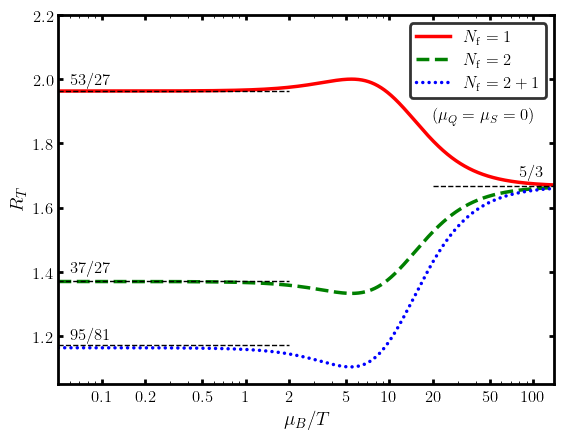

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Method of Adaptive median filter with larger kernel for high x values

# Set global frame thickness
plt.rcParams['axes.linewidth'] = 2.0  # Thickness of the frame
plt.rcParams['xtick.major.width'] = 2.0  # Thickness of the x-ticks
plt.rcParams['ytick.major.width'] = 2.0  # Thickness of the y-ticks
# Set global legend frame thickness
plt.rcParams['legend.edgecolor'] = 'black' # Ensures the box is black
plt.rcParams['patch.linewidth'] = 2.0      # This often controls legend line thickness

def adaptive_median_filter(x_data, y_data, threshold_x=None):
    if threshold_x is None:
        threshold_x = np.percentile(x_data, 70)  # Use 70th percentile as threshold
    
    y_filtered = np.copy(y_data)
    
    # Apply different kernel sizes based on x value
    for i in range(len(x_data)):
        if x_data[i] < threshold_x:
            kernel_size = 5  # Smaller kernel for low x values
        else:
            kernel_size = 15  # Much larger kernel for high x values
        
        # Apply median filter in a window around current point
        start_idx = max(0, i - kernel_size//2)
        end_idx = min(len(y_data), i + kernel_size//2 + 1)
        y_filtered[i] = np.median(y_data[start_idx:end_idx])
    
    return y_filtered

# Updated to use RkT1t as the x-axis, and RkT1, RkT2, RkT3 as the y-axes
y_ad1 = adaptive_median_filter(RkT1t, RkT1)
y_ad2 = adaptive_median_filter(RkT1t, RkT2)
y_ad3 = adaptive_median_filter(RkT1t, RkT3)


# 1. Plot the data
plt.plot(RkT1t, y_ad1, color='red', linestyle='solid', linewidth=2.5, label='Nfu')
plt.plot(RkT1t, y_ad2, color='green', linestyle='dashed', linewidth=2.5, label='Nfud')

# Updated the third curve to use the dense, native round dot tuple pattern
plt.plot(RkT1t, y_ad3, color='blue', linestyle=(0, (0.01, 1.8)), linewidth=2.5, dash_capstyle='round', label='Nfuds')



# 2. Convert X-axis to Logarithmic Scale
plt.xscale('log')

# 3. Adding Regional Horizontal Black Dashed Lines
plt.hlines(y=53/27, xmin=0.05, xmax=2, color='black', linestyle='--', linewidth=1)
plt.hlines(y=37/27, xmin=0.05, xmax=2, color='black', linestyle='--', linewidth=1)
plt.hlines(y=95/81, xmin=0.05, xmax=2, color='black', linestyle='--', linewidth=1)
plt.hlines(y=5/3, xmin=20, xmax=140, color='black', linestyle='--', linewidth=1)


# 4. Adding Texts on the plot.
plt.text(0.06, 1.985, "53/27", fontsize=12, color='black', fontweight='bold')
plt.text(0.06, 1.4, "37/27", fontsize=12, color='black', fontweight='bold')
plt.text(0.06, 1.193, "95/81", fontsize=12, color='black', fontweight='bold')
plt.text(80, 1.7, "5/3", fontsize=12, color='black', fontweight='bold')
plt.text(20, 1.87, "$(\\mu_{Q} = \\mu_{S} =0)$", fontsize=12, color='black', fontweight='bold')

# 5. Handle custom tick labels without trailing zeros (0.1, 0.5, 1, 5, 10, etc.)
# Adjust this list to match the actual temperature range of your data
custom_ticks = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100]
custom_labels = ["%g" % val for val in custom_ticks]

plt.xticks(custom_ticks, custom_labels)

# 6. Hide auto-generated minor labels to prevent cluttering
plt.gca().xaxis.set_minor_formatter(ticker.NullFormatter())

# 7. Mirror the ticks to all sides and point them inward
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)

# 8. Labels, Legends, and Formatting
plt.xlabel("$\\mu_B/T$", fontsize=14)
plt.ylabel("$R_{T}$", fontsize=14)
plt.legend(["$N_{\\rm f} = 1$", "$N_{\\rm f} = 2$", "$N_{\\rm f} = 2+1$"], loc="upper right")

plt.margins(x=0)

# 9. Manually fixing the Plot Range
plt.ylim(1.05, 2.2)

# 10. Save the final figure
plt.savefig('R3.pdf', bbox_inches='tight', pad_inches=0.1)